# 07 - Compare Source-wise Benchmark Results

This notebook summarizes the final PCB defect detection benchmark.

It reads model result CSV files from:

```text
reports/tables/
```

and writes consolidated tables/figures to:

```text
reports/tables/
reports/figures/
```

Expected models:

1. YOLOv11s
2. RT-DETR-L
3. Faster R-CNN ResNet50-FPN
4. YOLOv11s + CBAMLite + BiFPNLite + P2
5. PCBNet-RTDETR-HybridOpt

Main questions:

- Which model performs best overall?
- Which model is most stable across source datasets?
- Which source is hardest?
- Which classes remain weak, especially `spur`, `mouse_bite`, and `short`?
- Did custom/optimized models improve weak classes compared with stock baselines?

## 1. Imports and project paths

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for p in [start, *start.parents]:
        if (p / "README.md").exists() and (p / "reports").exists():
            return p
    if start.name == "notebooks":
        return start.parent
    return start

PROJECT_ROOT = find_project_root()
TABLE_DIR = PROJECT_ROOT / "reports" / "tables"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

CLASS_ORDER = [
    "missing_hole",
    "mouse_bite",
    "open_circuit",
    "short",
    "spur",
    "spurious_copper",
]

SOURCE_ORDER = ["Merged", "DeepPCB", "DsPCBSD", "HRIPCB", "UNKNOWN"]

MODEL_ORDER = [
    "YOLOv11s",
    "RT-DETR-L",
    "Faster R-CNN",
    "YOLOv11s-CBAMLite-BiFPNLite-P2",
    "PCBNet-RTDETR-HybridOpt",
]

WEAK_CLASSES = ["spur", "mouse_bite", "short"]

print("PROJECT_ROOT:", PROJECT_ROOT)
print("TABLE_DIR:", TABLE_DIR)
print("FIGURE_DIR:", FIGURE_DIR)

PROJECT_ROOT: d:\pcb-defect-detection-benchmark
TABLE_DIR: d:\pcb-defect-detection-benchmark\reports\tables
FIGURE_DIR: d:\pcb-defect-detection-benchmark\reports\figures


## 2. Helper functions

In [2]:
def standardize_metric_columns(df):
    rename_map = {
        "mAP50-95": "mAP50_95",
        "map50_95": "mAP50_95",
        "map50-95": "mAP50_95",
        "map50": "mAP50",
        "precision(B)": "precision",
        "recall(B)": "recall",
    }
    return df.rename(columns={c: rename_map.get(c, c) for c in df.columns})

def infer_model_display_name(row_or_path):
    text = str(row_or_path).lower()

    if isinstance(row_or_path, (pd.Series, dict)):
        values = []
        for key in ["model_name", "experiment", "weights", "source_file"]:
            if key in row_or_path and pd.notna(row_or_path[key]):
                values.append(str(row_or_path[key]).lower())
        text = " ".join(values)

    if "cbamlite" in text or "bifpnlite" in text or "_p2" in text:
        return "YOLOv11s-CBAMLite-BiFPNLite-P2"
    if "hybridopt" in text or "pcbnet" in text:
        return "PCBNet-RTDETR-HybridOpt"
    if "faster" in text or "faster_rcnn" in text:
        return "Faster R-CNN"
    if "rtdetr" in text or "rt_detr" in text or "rt-detr" in text:
        return "RT-DETR-L"
    if "yolo11" in text or "yolov11" in text:
        return "YOLOv11s"

    return "UNKNOWN_MODEL"

def read_csv_safely(path):
    df = pd.read_csv(path)
    df = standardize_metric_columns(df)
    df["source_file"] = path.name

    if "model_display_name" not in df.columns:
        df["model_display_name"] = df.apply(infer_model_display_name, axis=1)

    mask = df["model_display_name"].eq("UNKNOWN_MODEL")
    if mask.any():
        df.loc[mask, "model_display_name"] = infer_model_display_name(path.name)

    return df

def sort_model_source(df):
    df = df.copy()

    if "model_display_name" in df.columns:
        df["model_order"] = df["model_display_name"].apply(
            lambda x: MODEL_ORDER.index(x) if x in MODEL_ORDER else len(MODEL_ORDER)
        )

    if "test_source" in df.columns:
        df["source_order"] = df["test_source"].apply(
            lambda x: SOURCE_ORDER.index(x) if x in SOURCE_ORDER else len(SOURCE_ORDER)
        )

    sort_cols = [c for c in ["model_order", "source_order", "class_id"] if c in df.columns]
    if sort_cols:
        df = df.sort_values(sort_cols)

    return df.drop(columns=[c for c in ["model_order", "source_order"] if c in df.columns])

def save_table(df, name, index=False):
    out = TABLE_DIR / name
    df.to_csv(out, index=index)
    print("Saved:", out)
    return out

def save_figure(name):
    out = FIGURE_DIR / name
    plt.tight_layout()
    plt.savefig(out, dpi=180, bbox_inches="tight")
    print("Saved:", out)
    plt.show()
    return out

def format_display_df(df, digits=4):
    out = df.copy()
    num_cols = out.select_dtypes(include=[np.number]).columns
    for c in num_cols:
        out[c] = out[c].round(digits)
    return out

def markdown_table(df):
    work = df.copy()
    num_cols = work.select_dtypes(include=[np.number]).columns
    for c in num_cols:
        work[c] = work[c].map(lambda x: "" if pd.isna(x) else f"{x:.4f}")
    return work.to_markdown(index=False)

## 3. Load all source-wise result CSV files

In [3]:
summary_files = sorted(TABLE_DIR.glob("*sourcewise_summary_metrics.csv"))
per_class_files = sorted(TABLE_DIR.glob("*sourcewise_per_class_map.csv"))

print("Summary files:")
for p in summary_files:
    print("-", p.name)

print("\nPer-class files:")
for p in per_class_files:
    print("-", p.name)

assert len(summary_files) > 0, "No *_sourcewise_summary_metrics.csv files found in reports/tables."
assert len(per_class_files) > 0, "No *_sourcewise_per_class_map.csv files found in reports/tables."

summary_df = pd.concat([read_csv_safely(p) for p in summary_files], ignore_index=True)
per_class_df = pd.concat([read_csv_safely(p) for p in per_class_files], ignore_index=True)

summary_df = sort_model_source(summary_df)
per_class_df = sort_model_source(per_class_df)

if "test_source" in summary_df.columns:
    summary_df = summary_df[summary_df["test_source"].isin(SOURCE_ORDER)].copy()

if "test_source" in per_class_df.columns:
    per_class_df = per_class_df[per_class_df["test_source"].isin(SOURCE_ORDER)].copy()

display(format_display_df(summary_df))
display(format_display_df(per_class_df.head(30)))

save_table(summary_df, "all_models_sourcewise_summary_metrics.csv")
save_table(per_class_df, "all_models_sourcewise_per_class_map.csv")

Summary files:
- faster_rcnn_resnet50_fpn_final_clean_6cls_e42_sourcewise_summary_metrics.csv
- pcbnet_rtdetr_l_hybridopt_final_clean_6cls_e50_img768_sourcewise_summary_metrics.csv
- rtdetr_l_final_clean_6cls_e50_sourcewise_summary_metrics.csv
- yolov11s_cbamlite_bifpnlite_p2_final_clean_6cls_e50_sourcewise_summary_metrics.csv
- yolov11s_final_clean_6cls_e50_sourcewise_summary_metrics.csv

Per-class files:
- faster_rcnn_resnet50_fpn_final_clean_6cls_e42_sourcewise_per_class_map.csv
- pcbnet_rtdetr_l_hybridopt_final_clean_6cls_e50_img768_sourcewise_per_class_map.csv
- rtdetr_l_final_clean_6cls_e50_sourcewise_per_class_map.csv
- yolov11s_cbamlite_bifpnlite_p2_final_clean_6cls_e50_sourcewise_per_class_map.csv
- yolov11s_final_clean_6cls_e50_sourcewise_per_class_map.csv


,experiment,model_name,test_source,weights,precision,recall,f1,mAP50,mAP50_95,inference_ms_per_image,FPS,tp,fp,fn,score_threshold_for_pr,iou_threshold_for_pr,max_detections_per_image,source_file,model_display_name
16,yolov11s_final_clean_6cls_e50,yolo11s.pt,Merged,/kaggle/working/runs/detect/PCB_Baseline/yolov...,0.8529,0.8053,0.8285,0.8788,0.5761,11.0143,90.7908,NaN,NaN,NaN,NaN,NaN,NaN,yolov11s_final_clean_6cls_e50_sourcewise_summa...,YOLOv11s
17,yolov11s_final_clean_6cls_e50,yolo11s.pt,DeepPCB,/kaggle/working/runs/detect/PCB_Baseline/yolov...,0.9497,0.9379,0.9437,0.9750,0.7538,11.5335,86.7036,NaN,NaN,NaN,NaN,NaN,NaN,yolov11s_final_clean_6cls_e50_sourcewise_summa...,YOLOv11s
18,yolov11s_final_clean_6cls_e50,yolo11s.pt,DsPCBSD,/kaggle/working/runs/detect/PCB_Baseline/yolov...,0.7977,0.7516,0.7740,0.8300,0.4874,12.3751,80.8077,NaN,NaN,NaN,NaN,NaN,NaN,yolov11s_final_clean_6cls_e50_sourcewise_summa...,YOLOv11s
19,yolov11s_final_clean_6cls_e50,yolo11s.pt,HRIPCB,/kaggle/working/runs/detect/PCB_Baseline/yolov...,0.8048,0.6736,0.7334,0.7233,0.3060,12.0578,82.9341,NaN,NaN,NaN,NaN,NaN,NaN,yolov11s_final_clean_6cls_e50_sourcewise_summa...,YOLOv11s
8,rtdetr_l_final_clean_6cls_e50,rtdetr-l.pt,Merged,/kaggle/working/runs/detect/PCB_Baseline/rtdet...,0.9215,0.8970,0.9090,0.9315,0.6595,42.1156,23.7442,NaN,NaN,NaN,NaN,NaN,NaN,rtdetr_l_final_clean_6cls_e50_sourcewise_summa...,RT-DETR-L
9,rtdetr_l_final_clean_6cls_e50,rtdetr-l.pt,DeepPCB,/kaggle/working/runs/detect/PCB_Baseline/rtdet...,0.9875,0.9705,0.9789,0.9862,0.8345,40.6317,24.6113,NaN,NaN,NaN,NaN,NaN,NaN,rtdetr_l_final_clean_6cls_e50_sourcewise_summa...,RT-DETR-L
10,rtdetr_l_final_clean_6cls_e50,rtdetr-l.pt,DsPCBSD,/kaggle/working/runs/detect/PCB_Baseline/rtdet...,0.8594,0.8404,0.8498,0.8699,0.5399,42.5988,23.4749,NaN,NaN,NaN,NaN,NaN,NaN,rtdetr_l_final_clean_6cls_e50_sourcewise_summa...,RT-DETR-L
11,rtdetr_l_final_clean_6cls_e50,rtdetr-l.pt,HRIPCB,/kaggle/working/runs/detect/PCB_Baseline/rtdet...,0.9742,0.9507,0.9623,0.9613,0.5198,40.1439,24.9104,NaN,NaN,NaN,NaN,NaN,NaN,rtdetr_l_final_clean_6cls_e50_sourcewise_summa...,RT-DETR-L
0,faster_rcnn_resnet50_fpn_final_clean_6cls_e42,faster_rcnn_resnet50_fpn,Merged,/kaggle/working/faster_rcnn_checkpoints/faster...,0.7823,0.9004,0.8372,0.8924,0.5918,89.0116,11.2345,4819.0,1341.0,533.0,0.25,0.5,100.0,faster_rcnn_resnet50_fpn_final_clean_6cls_e42_...,Faster R-CNN
1,faster_rcnn_resnet50_fpn_final_clean_6cls_e42,faster_rcnn_resnet50_fpn,DeepPCB,/kaggle/working/faster_rcnn_checkpoints/faster...,0.9148,0.9778,0.9452,0.9744,0.7773,89.6617,11.1530,1803.0,168.0,41.0,0.25,0.5,100.0,faster_rcnn_resnet50_fpn_final_clean_6cls_e42_...,Faster R-CNN


,experiment,model_name,test_source,class_id,class_name,mAP50_95,source_file,model_display_name
96,yolov11s_final_clean_6cls_e50,yolo11s.pt,Merged,0,missing_hole,0.7903,yolov11s_final_clean_6cls_e50_sourcewise_per_c...,YOLOv11s
97,yolov11s_final_clean_6cls_e50,yolo11s.pt,Merged,1,mouse_bite,0.5162,yolov11s_final_clean_6cls_e50_sourcewise_per_c...,YOLOv11s
98,yolov11s_final_clean_6cls_e50,yolo11s.pt,Merged,2,open_circuit,0.5710,yolov11s_final_clean_6cls_e50_sourcewise_per_c...,YOLOv11s
99,yolov11s_final_clean_6cls_e50,yolo11s.pt,Merged,3,short,0.5144,yolov11s_final_clean_6cls_e50_sourcewise_per_c...,YOLOv11s
100,yolov11s_final_clean_6cls_e50,yolo11s.pt,Merged,4,spur,0.4265,yolov11s_final_clean_6cls_e50_sourcewise_per_c...,YOLOv11s
101,yolov11s_final_clean_6cls_e50,yolo11s.pt,Merged,5,spurious_copper,0.6382,yolov11s_final_clean_6cls_e50_sourcewise_per_c...,YOLOv11s
102,yolov11s_final_clean_6cls_e50,yolo11s.pt,DeepPCB,0,missing_hole,0.8547,yolov11s_final_clean_6cls_e50_sourcewise_per_c...,YOLOv11s
103,yolov11s_final_clean_6cls_e50,yolo11s.pt,DeepPCB,1,mouse_bite,0.7359,yolov11s_final_clean_6cls_e50_sourcewise_per_c...,YOLOv11s
104,yolov11s_final_clean_6cls_e50,yolo11s.pt,DeepPCB,2,open_circuit,0.6961,yolov11s_final_clean_6cls_e50_sourcewise_per_c...,YOLOv11s
105,yolov11s_final_clean_6cls_e50,yolo11s.pt,DeepPCB,3,short,0.6236,yolov11s_final_clean_6cls_e50_sourcewise_per_c...,YOLOv11s


Saved: d:\pcb-defect-detection-benchmark\reports\tables\all_models_sourcewise_summary_metrics.csv
Saved: d:\pcb-defect-detection-benchmark\reports\tables\all_models_sourcewise_per_class_map.csv


WindowsPath('d:/pcb-defect-detection-benchmark/reports/tables/all_models_sourcewise_per_class_map.csv')

## 4. Overall merged-test model comparison

In [4]:
metric_cols = [
    "precision",
    "recall",
    "f1",
    "mAP50",
    "mAP50_95",
    "inference_ms_per_image",
    "FPS",
]

available_metric_cols = [c for c in metric_cols if c in summary_df.columns]

merged_comparison_df = (
    summary_df[summary_df["test_source"] == "Merged"]
    [["model_display_name", "test_source", *available_metric_cols]]
    .drop_duplicates(subset=["model_display_name", "test_source"])
    .copy()
)

merged_comparison_df["model_order"] = merged_comparison_df["model_display_name"].apply(
    lambda x: MODEL_ORDER.index(x) if x in MODEL_ORDER else len(MODEL_ORDER)
)
merged_comparison_df = merged_comparison_df.sort_values("model_order").drop(columns="model_order")

display(format_display_df(merged_comparison_df))
save_table(merged_comparison_df, "model_comparison_merged_test.csv")

best_row = merged_comparison_df.sort_values("mAP50_95", ascending=False).iloc[0]
print(
    "Best merged-test model by mAP50-95:",
    best_row["model_display_name"],
    "| mAP50-95 =",
    round(float(best_row["mAP50_95"]), 4),
)

,model_display_name,test_source,precision,recall,f1,mAP50,mAP50_95,inference_ms_per_image,FPS
16,YOLOv11s,Merged,0.8529,0.8053,0.8285,0.8788,0.5761,11.0143,90.7908
8,RT-DETR-L,Merged,0.9215,0.8970,0.9090,0.9315,0.6595,42.1156,23.7442
0,Faster R-CNN,Merged,0.7823,0.9004,0.8372,0.8924,0.5918,89.0116,11.2345
12,YOLOv11s-CBAMLite-BiFPNLite-P2,Merged,0.8428,0.8146,0.8284,0.8818,0.5764,16.3764,61.0634
4,PCBNet-RTDETR-HybridOpt,Merged,0.8945,0.8767,0.8855,0.9177,0.6112,47.8226,20.9106


Saved: d:\pcb-defect-detection-benchmark\reports\tables\model_comparison_merged_test.csv
Best merged-test model by mAP50-95: RT-DETR-L | mAP50-95 = 0.6595


## 5. Source-wise overall comparison

In [5]:
sourcewise_pivot = summary_df.pivot_table(
    index="model_display_name",
    columns="test_source",
    values="mAP50_95",
    aggfunc="first",
)

sourcewise_pivot = sourcewise_pivot.reindex(
    index=[m for m in MODEL_ORDER if m in sourcewise_pivot.index],
    columns=[s for s in SOURCE_ORDER if s in sourcewise_pivot.columns],
)

source_cols = [c for c in ["DeepPCB", "DsPCBSD", "HRIPCB"] if c in sourcewise_pivot.columns]

sourcewise_pivot["mean_source_mAP50_95"] = sourcewise_pivot[source_cols].mean(axis=1)
sourcewise_pivot["std_source_mAP50_95"] = sourcewise_pivot[source_cols].std(axis=1)
sourcewise_pivot["min_source_mAP50_95"] = sourcewise_pivot[source_cols].min(axis=1)

sourcewise_pivot = sourcewise_pivot.reset_index()

display(format_display_df(sourcewise_pivot))
save_table(sourcewise_pivot, "model_comparison_sourcewise_pivot.csv")

test_source,model_display_name,Merged,DeepPCB,DsPCBSD,HRIPCB,mean_source_mAP50_95,std_source_mAP50_95,min_source_mAP50_95
0,YOLOv11s,0.5761,0.7538,0.4874,0.3060,0.5158,0.2252,0.3060
1,RT-DETR-L,0.6595,0.8345,0.5399,0.5198,0.6314,0.1762,0.5198
2,Faster R-CNN,0.5918,0.7773,0.5121,0.3919,0.5604,0.1972,0.3919
3,YOLOv11s-CBAMLite-BiFPNLite-P2,0.5764,0.7517,0.4721,0.3821,0.5353,0.1927,0.3821
4,PCBNet-RTDETR-HybridOpt,0.6112,0.7596,0.5068,0.4731,0.5798,0.1566,0.4731


Saved: d:\pcb-defect-detection-benchmark\reports\tables\model_comparison_sourcewise_pivot.csv


WindowsPath('d:/pcb-defect-detection-benchmark/reports/tables/model_comparison_sourcewise_pivot.csv')

## 6. Plot: mAP50-95 on merged test by model

Saved: d:\pcb-defect-detection-benchmark\reports\figures\model_comparison_merged_map50_95.png


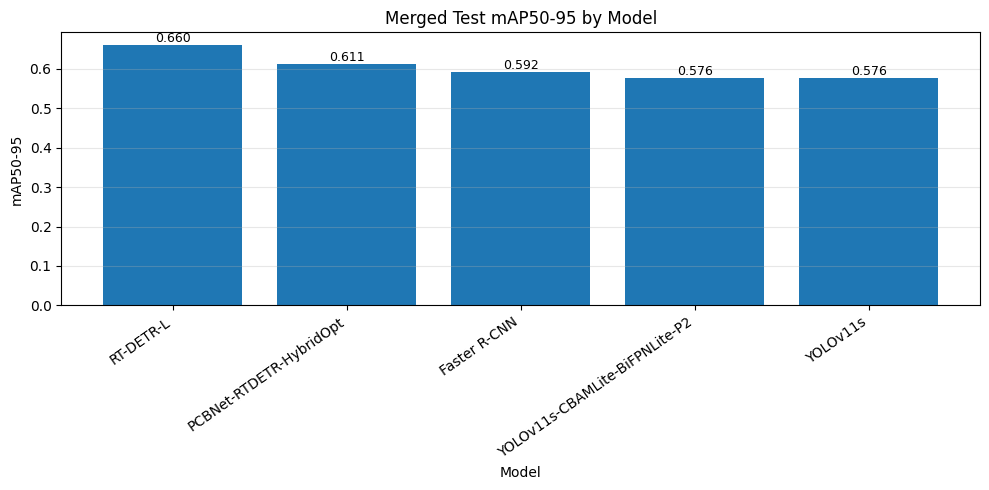

WindowsPath('d:/pcb-defect-detection-benchmark/reports/figures/model_comparison_merged_map50_95.png')

In [6]:
plot_df = merged_comparison_df.copy()
plot_df = plot_df.sort_values("mAP50_95", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(plot_df["model_display_name"], plot_df["mAP50_95"])
plt.title("Merged Test mAP50-95 by Model")
plt.xlabel("Model")
plt.ylabel("mAP50-95")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y", alpha=0.3)

for i, v in enumerate(plot_df["mAP50_95"]):
    plt.text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)

save_figure("model_comparison_merged_map50_95.png")

## 7. Plot: source-wise mAP50-95 by model

Saved: d:\pcb-defect-detection-benchmark\reports\figures\model_comparison_sourcewise_map50_95.png


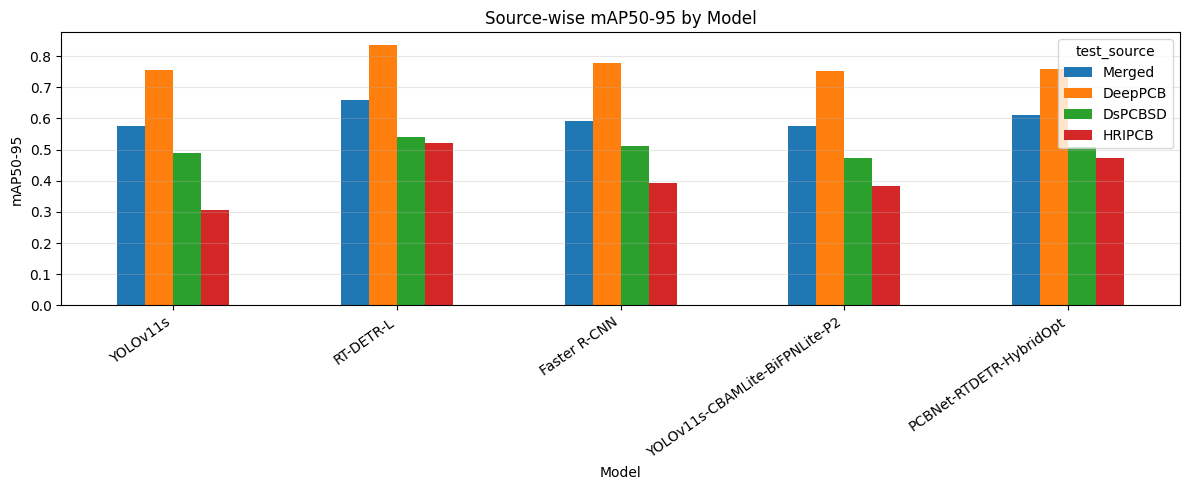

WindowsPath('d:/pcb-defect-detection-benchmark/reports/figures/model_comparison_sourcewise_map50_95.png')

In [7]:
plot_sources = [s for s in ["Merged", "DeepPCB", "DsPCBSD", "HRIPCB"] if s in summary_df["test_source"].unique()]

plot_pivot = summary_df.pivot_table(
    index="model_display_name",
    columns="test_source",
    values="mAP50_95",
    aggfunc="first",
)

plot_pivot = plot_pivot.reindex(index=[m for m in MODEL_ORDER if m in plot_pivot.index])
plot_pivot = plot_pivot[plot_sources]

ax = plot_pivot.plot(kind="bar", figsize=(12, 5))
ax.set_title("Source-wise mAP50-95 by Model")
ax.set_xlabel("Model")
ax.set_ylabel("mAP50-95")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=35, ha="right")

save_figure("model_comparison_sourcewise_map50_95.png")

## 8. Per-class comparison on merged test

In [8]:
merged_per_class_df = per_class_df[per_class_df["test_source"] == "Merged"].copy()

per_class_pivot = merged_per_class_df.pivot_table(
    index="class_name",
    columns="model_display_name",
    values="mAP50_95",
    aggfunc="first",
)

per_class_pivot = per_class_pivot.reindex(
    index=[c for c in CLASS_ORDER if c in per_class_pivot.index],
    columns=[m for m in MODEL_ORDER if m in per_class_pivot.columns],
)

display(format_display_df(per_class_pivot.reset_index()))

per_class_pivot.reset_index().to_csv(TABLE_DIR / "per_class_comparison_merged_test_pivot.csv", index=False)
print("Saved:", TABLE_DIR / "per_class_comparison_merged_test_pivot.csv")

class_difficulty_df = per_class_pivot.copy()
class_difficulty_df["mean_mAP50_95"] = class_difficulty_df.mean(axis=1)
class_difficulty_df["min_mAP50_95"] = class_difficulty_df.min(axis=1)
class_difficulty_df["max_mAP50_95"] = class_difficulty_df.max(axis=1)
class_difficulty_df = class_difficulty_df.reset_index().sort_values("mean_mAP50_95")

display(format_display_df(class_difficulty_df))
save_table(class_difficulty_df, "class_difficulty_summary_merged_test.csv")

model_display_name,class_name,YOLOv11s,RT-DETR-L,Faster R-CNN,YOLOv11s-CBAMLite-BiFPNLite-P2,PCBNet-RTDETR-HybridOpt
0,missing_hole,0.7903,0.8618,0.8195,0.7912,0.8028
1,mouse_bite,0.5162,0.5861,0.5188,0.5119,0.5381
2,open_circuit,0.5710,0.6556,0.5795,0.5628,0.6202
3,short,0.5144,0.6376,0.5259,0.5292,0.5891
4,spur,0.4265,0.4847,0.4375,0.4353,0.4543
5,spurious_copper,0.6382,0.7314,0.6697,0.6282,0.6628


Saved: d:\pcb-defect-detection-benchmark\reports\tables\per_class_comparison_merged_test_pivot.csv


model_display_name,class_name,YOLOv11s,RT-DETR-L,Faster R-CNN,YOLOv11s-CBAMLite-BiFPNLite-P2,PCBNet-RTDETR-HybridOpt,mean_mAP50_95,min_mAP50_95,max_mAP50_95
4,spur,0.4265,0.4847,0.4375,0.4353,0.4543,0.4476,0.4265,0.4847
1,mouse_bite,0.5162,0.5861,0.5188,0.5119,0.5381,0.5342,0.5119,0.5861
3,short,0.5144,0.6376,0.5259,0.5292,0.5891,0.5592,0.5144,0.6376
2,open_circuit,0.5710,0.6556,0.5795,0.5628,0.6202,0.5978,0.5628,0.6556
5,spurious_copper,0.6382,0.7314,0.6697,0.6282,0.6628,0.6661,0.6282,0.7314
0,missing_hole,0.7903,0.8618,0.8195,0.7912,0.8028,0.8131,0.7903,0.8618


Saved: d:\pcb-defect-detection-benchmark\reports\tables\class_difficulty_summary_merged_test.csv


WindowsPath('d:/pcb-defect-detection-benchmark/reports/tables/class_difficulty_summary_merged_test.csv')

## 9. Plot: per-class mAP50-95 on merged test

Saved: d:\pcb-defect-detection-benchmark\reports\figures\per_class_comparison_merged_test_map50_95.png


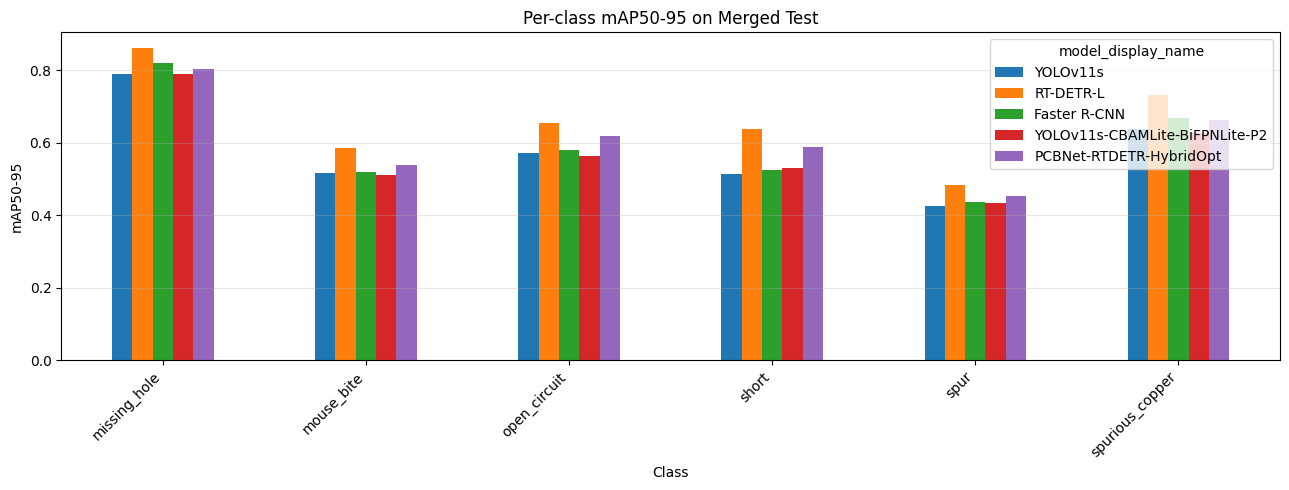

WindowsPath('d:/pcb-defect-detection-benchmark/reports/figures/per_class_comparison_merged_test_map50_95.png')

In [9]:
ax = per_class_pivot.plot(kind="bar", figsize=(13, 5))
ax.set_title("Per-class mAP50-95 on Merged Test")
ax.set_xlabel("Class")
ax.set_ylabel("mAP50-95")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45, ha="right")

save_figure("per_class_comparison_merged_test_map50_95.png")

## 10. Weak-class focus: spur, mouse_bite, short

In [10]:
weak_class_df = per_class_df[per_class_df["class_name"].isin(WEAK_CLASSES)].copy()
weak_class_df = sort_model_source(weak_class_df)

display(format_display_df(weak_class_df))
save_table(weak_class_df, "weak_class_focus_sourcewise.csv")

weak_merged_pivot = weak_class_df[weak_class_df["test_source"] == "Merged"].pivot_table(
    index="class_name",
    columns="model_display_name",
    values="mAP50_95",
    aggfunc="first",
)

weak_merged_pivot = weak_merged_pivot.reindex(
    index=[c for c in WEAK_CLASSES if c in weak_merged_pivot.index],
    columns=[m for m in MODEL_ORDER if m in weak_merged_pivot.columns],
)

display(format_display_df(weak_merged_pivot.reset_index()))

weak_merged_pivot.reset_index().to_csv(TABLE_DIR / "weak_class_comparison_merged_test_pivot.csv", index=False)
print("Saved:", TABLE_DIR / "weak_class_comparison_merged_test_pivot.csv")

,experiment,model_name,test_source,class_id,class_name,mAP50_95,source_file,model_display_name
97,yolov11s_final_clean_6cls_e50,yolo11s.pt,Merged,1,mouse_bite,0.5162,yolov11s_final_clean_6cls_e50_sourcewise_per_c...,YOLOv11s
99,yolov11s_final_clean_6cls_e50,yolo11s.pt,Merged,3,short,0.5144,yolov11s_final_clean_6cls_e50_sourcewise_per_c...,YOLOv11s
100,yolov11s_final_clean_6cls_e50,yolo11s.pt,Merged,4,spur,0.4265,yolov11s_final_clean_6cls_e50_sourcewise_per_c...,YOLOv11s
103,yolov11s_final_clean_6cls_e50,yolo11s.pt,DeepPCB,1,mouse_bite,0.7359,yolov11s_final_clean_6cls_e50_sourcewise_per_c...,YOLOv11s
105,yolov11s_final_clean_6cls_e50,yolo11s.pt,DeepPCB,3,short,0.6236,yolov11s_final_clean_6cls_e50_sourcewise_per_c...,YOLOv11s
106,yolov11s_final_clean_6cls_e50,yolo11s.pt,DeepPCB,4,spur,0.7268,yolov11s_final_clean_6cls_e50_sourcewise_per_c...,YOLOv11s
109,yolov11s_final_clean_6cls_e50,yolo11s.pt,DsPCBSD,1,mouse_bite,0.3819,yolov11s_final_clean_6cls_e50_sourcewise_per_c...,YOLOv11s
111,yolov11s_final_clean_6cls_e50,yolo11s.pt,DsPCBSD,3,short,0.4794,yolov11s_final_clean_6cls_e50_sourcewise_per_c...,YOLOv11s
112,yolov11s_final_clean_6cls_e50,yolo11s.pt,DsPCBSD,4,spur,0.3168,yolov11s_final_clean_6cls_e50_sourcewise_per_c...,YOLOv11s
115,yolov11s_final_clean_6cls_e50,yolo11s.pt,HRIPCB,1,mouse_bite,0.2760,yolov11s_final_clean_6cls_e50_sourcewise_per_c...,YOLOv11s


Saved: d:\pcb-defect-detection-benchmark\reports\tables\weak_class_focus_sourcewise.csv


model_display_name,class_name,YOLOv11s,RT-DETR-L,Faster R-CNN,YOLOv11s-CBAMLite-BiFPNLite-P2,PCBNet-RTDETR-HybridOpt
0,spur,0.4265,0.4847,0.4375,0.4353,0.4543
1,mouse_bite,0.5162,0.5861,0.5188,0.5119,0.5381
2,short,0.5144,0.6376,0.5259,0.5292,0.5891


Saved: d:\pcb-defect-detection-benchmark\reports\tables\weak_class_comparison_merged_test_pivot.csv


## 11. Plot: weak classes on merged test

Saved: d:\pcb-defect-detection-benchmark\reports\figures\weak_class_comparison_merged_test_map50_95.png


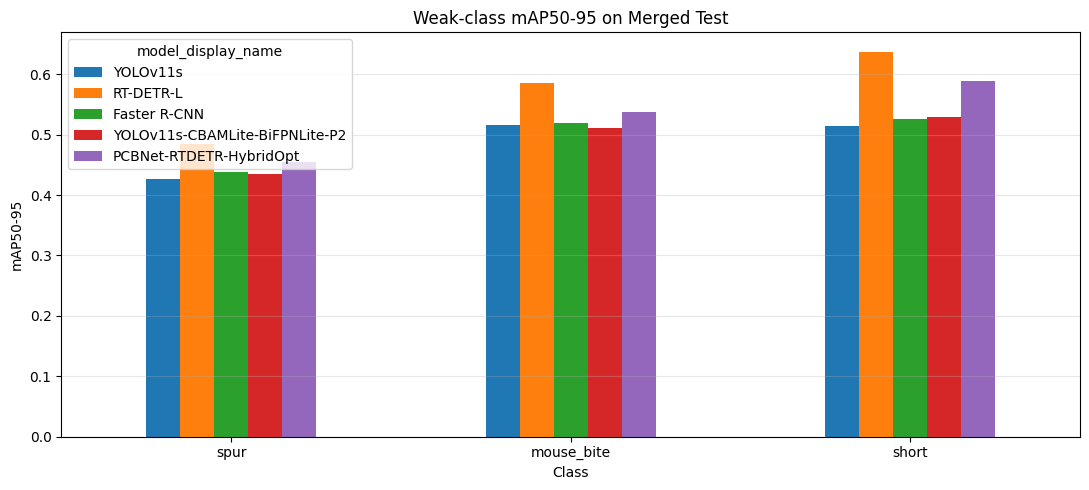

WindowsPath('d:/pcb-defect-detection-benchmark/reports/figures/weak_class_comparison_merged_test_map50_95.png')

In [11]:
ax = weak_merged_pivot.plot(kind="bar", figsize=(11, 5))
ax.set_title("Weak-class mAP50-95 on Merged Test")
ax.set_xlabel("Class")
ax.set_ylabel("mAP50-95")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=0)

save_figure("weak_class_comparison_merged_test_map50_95.png")

## 12. Source difficulty analysis

In [12]:
source_difficulty_df = summary_df.pivot_table(
    index="test_source",
    values="mAP50_95",
    aggfunc=["mean", "std", "min", "max"],
)

source_difficulty_df.columns = [
    "mean_mAP50_95",
    "std_mAP50_95",
    "min_mAP50_95",
    "max_mAP50_95",
]

source_difficulty_df = source_difficulty_df.reindex([s for s in SOURCE_ORDER if s in source_difficulty_df.index])
source_difficulty_df = source_difficulty_df.reset_index()

display(format_display_df(source_difficulty_df))
save_table(source_difficulty_df, "source_difficulty_summary.csv")

hardest_source = source_difficulty_df.sort_values("mean_mAP50_95").iloc[0]
print(
    "Hardest source by mean mAP50-95:",
    hardest_source["test_source"],
    "| mean mAP50-95 =",
    round(float(hardest_source["mean_mAP50_95"]), 4),
)

,test_source,mean_mAP50_95,std_mAP50_95,min_mAP50_95,max_mAP50_95
0,Merged,0.6030,0.0347,0.5761,0.6595
1,DeepPCB,0.7754,0.0346,0.7517,0.8345
2,DsPCBSD,0.5036,0.0258,0.4721,0.5399
3,HRIPCB,0.4146,0.0834,0.3060,0.5198


Saved: d:\pcb-defect-detection-benchmark\reports\tables\source_difficulty_summary.csv
Hardest source by mean mAP50-95: HRIPCB | mean mAP50-95 = 0.4146


## 13. Best model per source and per class

In [13]:
best_model_per_source_df = (
    summary_df.sort_values("mAP50_95", ascending=False)
    .groupby("test_source", as_index=False)
    .first()
    [["test_source", "model_display_name", "mAP50_95", "mAP50", "precision", "recall"]]
)

best_model_per_source_df["source_order"] = best_model_per_source_df["test_source"].apply(
    lambda x: SOURCE_ORDER.index(x) if x in SOURCE_ORDER else len(SOURCE_ORDER)
)
best_model_per_source_df = best_model_per_source_df.sort_values("source_order").drop(columns="source_order")

display(format_display_df(best_model_per_source_df))
save_table(best_model_per_source_df, "best_model_per_source.csv")

best_model_per_class_merged_df = (
    merged_per_class_df.sort_values("mAP50_95", ascending=False)
    .groupby("class_name", as_index=False)
    .first()
    [["class_name", "model_display_name", "mAP50_95"]]
)

best_model_per_class_merged_df["class_order"] = best_model_per_class_merged_df["class_name"].apply(
    lambda x: CLASS_ORDER.index(x) if x in CLASS_ORDER else len(CLASS_ORDER)
)
best_model_per_class_merged_df = best_model_per_class_merged_df.sort_values("class_order").drop(columns="class_order")

display(format_display_df(best_model_per_class_merged_df))
save_table(best_model_per_class_merged_df, "best_model_per_class_merged_test.csv")

,test_source,model_display_name,mAP50_95,mAP50,precision,recall
3,Merged,RT-DETR-L,0.6595,0.9315,0.9215,0.8970
0,DeepPCB,RT-DETR-L,0.8345,0.9862,0.9875,0.9705
1,DsPCBSD,RT-DETR-L,0.5399,0.8699,0.8594,0.8404
2,HRIPCB,RT-DETR-L,0.5198,0.9613,0.9742,0.9507


Saved: d:\pcb-defect-detection-benchmark\reports\tables\best_model_per_source.csv


,class_name,model_display_name,mAP50_95
0,missing_hole,RT-DETR-L,0.8618
1,mouse_bite,RT-DETR-L,0.5861
2,open_circuit,RT-DETR-L,0.6556
3,short,RT-DETR-L,0.6376
4,spur,RT-DETR-L,0.4847
5,spurious_copper,RT-DETR-L,0.7314


Saved: d:\pcb-defect-detection-benchmark\reports\tables\best_model_per_class_merged_test.csv


WindowsPath('d:/pcb-defect-detection-benchmark/reports/tables/best_model_per_class_merged_test.csv')

## 14. Generate Markdown summary for README

In [14]:
readme_summary_lines = []

readme_summary_lines.append("## Benchmark Results")
readme_summary_lines.append("")
readme_summary_lines.append("### Overall comparison on merged test set")
readme_summary_lines.append("")

cols = ["model_display_name", "precision", "recall", "f1", "mAP50", "mAP50_95"]
if "FPS" in merged_comparison_df.columns:
    cols.append("FPS")

readme_summary_lines.append(markdown_table(merged_comparison_df[cols]))
readme_summary_lines.append("")
readme_summary_lines.append("### Best model per source")
readme_summary_lines.append("")
readme_summary_lines.append(markdown_table(best_model_per_source_df))
readme_summary_lines.append("")
readme_summary_lines.append("### Best model per class on merged test")
readme_summary_lines.append("")
readme_summary_lines.append(markdown_table(best_model_per_class_merged_df))
readme_summary_lines.append("")

readme_summary = "\n".join(readme_summary_lines)

summary_path = PROJECT_ROOT / "reports" / "benchmark_readme_summary.md"
summary_path.write_text(readme_summary, encoding="utf-8")

print("Saved:", summary_path)
print("\n" + readme_summary)

Saved: d:\pcb-defect-detection-benchmark\reports\benchmark_readme_summary.md

## Benchmark Results

### Overall comparison on merged test set

| model_display_name             |   precision |   recall |     f1 |   mAP50 |   mAP50_95 |     FPS |
|:-------------------------------|------------:|---------:|-------:|--------:|-----------:|--------:|
| YOLOv11s                       |      0.8529 |   0.8053 | 0.8285 |  0.8788 |     0.5761 | 90.7908 |
| RT-DETR-L                      |      0.9215 |   0.897  | 0.909  |  0.9315 |     0.6595 | 23.7442 |
| Faster R-CNN                   |      0.7823 |   0.9004 | 0.8372 |  0.8924 |     0.5918 | 11.2345 |
| YOLOv11s-CBAMLite-BiFPNLite-P2 |      0.8428 |   0.8146 | 0.8284 |  0.8818 |     0.5764 | 61.0634 |
| PCBNet-RTDETR-HybridOpt        |      0.8945 |   0.8767 | 0.8855 |  0.9177 |     0.6112 | 20.9106 |

### Best model per source

| test_source   | model_display_name   |   mAP50_95 |   mAP50 |   precision |   recall |
|:--------------|:--------

## 15. Technical interpretation checklist

In [15]:
print("Interpretation checklist:")
print("1. Compare stock YOLOv11s vs custom YOLOv11s-P2 for weak classes.")
print("2. Compare stock RT-DETR-L vs PCBNet-RTDETR-HybridOpt.")
print("3. Check whether gains are consistent across DeepPCB, DsPCBSD, and HRIPCB.")
print("4. If a class remains weak across all models, prioritize error analysis over more model training.")
print("5. If only one source is weak, investigate source-domain shift or label convention differences.")
print("6. If high-resolution/HybridOpt improves spur or mouse_bite, small-object localization is likely important.")
print("7. Choose deployment candidate using mAP50-95 + FPS/training cost, not mAP alone.")

Interpretation checklist:
1. Compare stock YOLOv11s vs custom YOLOv11s-P2 for weak classes.
2. Compare stock RT-DETR-L vs PCBNet-RTDETR-HybridOpt.
3. Check whether gains are consistent across DeepPCB, DsPCBSD, and HRIPCB.
4. If a class remains weak across all models, prioritize error analysis over more model training.
5. If only one source is weak, investigate source-domain shift or label convention differences.
6. If high-resolution/HybridOpt improves spur or mouse_bite, small-object localization is likely important.
7. Choose deployment candidate using mAP50-95 + FPS/training cost, not mAP alone.


## Output files created by this notebook

Tables:

```text
reports/tables/all_models_sourcewise_summary_metrics.csv
reports/tables/all_models_sourcewise_per_class_map.csv
reports/tables/model_comparison_merged_test.csv
reports/tables/model_comparison_sourcewise_pivot.csv
reports/tables/per_class_comparison_merged_test_pivot.csv
reports/tables/class_difficulty_summary_merged_test.csv
reports/tables/weak_class_focus_sourcewise.csv
reports/tables/weak_class_comparison_merged_test_pivot.csv
reports/tables/source_difficulty_summary.csv
reports/tables/best_model_per_source.csv
reports/tables/best_model_per_class_merged_test.csv
```

Figures:

```text
reports/figures/model_comparison_merged_map50_95.png
reports/figures/model_comparison_sourcewise_map50_95.png
reports/figures/per_class_comparison_merged_test_map50_95.png
reports/figures/weak_class_comparison_merged_test_map50_95.png
```

README helper:

```text
reports/benchmark_readme_summary.md
```